# 06 – Análise de Sobrevivência
**Objetivo:** Aplicar técnicas de análise de sobrevivência para estimar as funções de probabilidade de sobrevivência ao longo do tempo de internação e modelar o risco (hazard) utilizando a Regressão de Cox.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Lifelines (Survival Analysis library)
# pip install lifelines
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Preparação dos Dados
A análise de sobrevivência requer a variável de **tempo** (`dias_permanencia` ou `tempo_sobrevida`). Como essas variáveis foram removidas da base reduzida (para evitar vazamento no ML), usaremos a **base_modelagem.csv** original e faremos uma seleção de features manuais de interesse clínico.

In [2]:
DATA_PATH = Path('../data/processed/base_modelagem.csv')
df = pd.read_csv(DATA_PATH, low_memory=False)

# Garantir formato correto
df['indicador_obito'] = pd.to_numeric(df['indicador_obito'], errors='coerce')
df['dias_permanencia'] = pd.to_numeric(df['dias_permanencia'], errors='coerce')

# Variáveis básicas para sobrevida
T = df['dias_permanencia']  # Tempo
E = df['indicador_obito']   # Evento (1 = Óbito, 0 = Censura/Alta)

print(f"Base carregada. Casos totais: {len(df)}")
print(f"Óbitos confirmados: {E.sum()}")

Base carregada. Casos totais: 48977
Óbitos confirmados: 3511


## 2. Estimador de Kaplan-Meier (Curva Global)
Plotar a curva de sobrevivência global da amostra ao longo dos dias de internação.

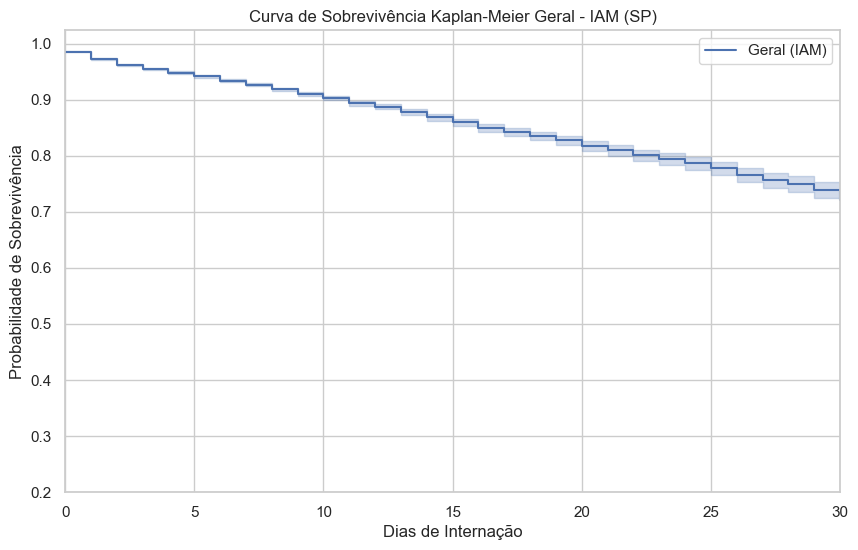

In [3]:
kmf = KaplanMeierFitter()
kmf.fit(durations=T, event_observed=E, label='Geral (IAM)')

kmf.plot_survival_function()
plt.title('Curva de Sobrevivência Kaplan-Meier Geral - IAM (SP)')
plt.ylabel('Probabilidade de Sobrevivência')
plt.xlabel('Dias de Internação')
plt.xlim(0, 30) # Foco no primeiro mês
plt.show()

## 3. Sobrevivência Estratificada
Comparar curvas de sobrevivência entre grupos (ex: Sexo, Caráter de Atendimento) usando o Log-Rank Test.

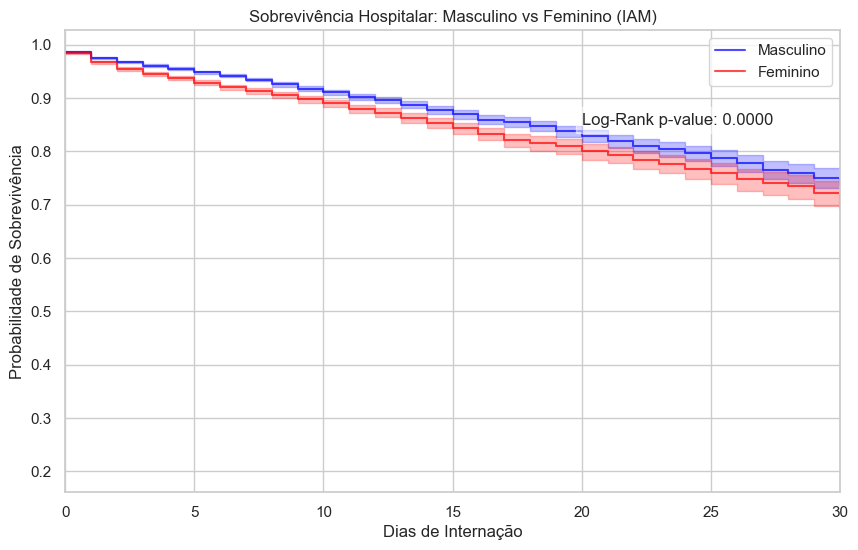

O teste estatístico mostra p-value de 7.4968e-14. Isso indica diferença significativa entre os sexos.


In [4]:
# Comparação entre Sexo
fig, ax = plt.subplots(figsize=(10, 6))

kmf_m = KaplanMeierFitter()
kmf_f = KaplanMeierFitter()

# 1 = Masculino, 3 = Feminino
mask_m = df['sexo'] == 1
mask_f = df['sexo'] == 3

# Ajustar e plotar Homens
kmf_m.fit(T[mask_m], event_observed=E[mask_m], label='Masculino')
kmf_m.plot_survival_function(ax=ax, color='blue', alpha=0.7)

# Ajustar e plotar Mulheres
kmf_f.fit(T[mask_f], event_observed=E[mask_f], label='Feminino')
kmf_f.plot_survival_function(ax=ax, color='red', alpha=0.7)

plt.title('Sobrevivência Hospitalar: Masculino vs Feminino (IAM)')
plt.ylabel('Probabilidade de Sobrevivência')
plt.xlabel('Dias de Internação')
plt.xlim(0, 30)

# Aplicar Log-Rank Test para checar significância estatística
results = logrank_test(T[mask_m], T[mask_f], event_observed_A=E[mask_m], event_observed_B=E[mask_f])
plt.text(20, 0.85, f"Log-Rank p-value: {results.p_value:.4f}", fontsize=12, bbox=dict(facecolor='white', alpha=0.5))

plt.show()
print(f"O teste estatístico mostra p-value de {results.p_value:.4e}. "
      f"Isso indica {'diferença' if results.p_value < 0.05 else 'nenhuma diferença'} significativa entre os sexos.")

## 4. Modelo de Riscos Proporcionais de Cox (CoxPH)
O modelo de Cox permite avaliar o efeito de múltiplas variáveis independentes sobre o risco de ocorrência do óbito (Hazard Ratio).

=== Resumo do Modelo de Riscos Proporcionais de Cox ===


<lifelines.CoxPHFitter: fitted with 48977 total observations, 45466 right-censored observations>
             duration col = 'dias_permanencia'
                event col = 'indicador_obito'
      baseline estimation = breslow
   number of observations = 48977
number of events observed = 3511
   partial log-likelihood = -34053.31
         time fit was run = 2026-06-08 18:33:06 UTC

---
                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                           
idade               0.04      1.04      0.00            0.04            0.05                1.04                1.05
sexo                0.11      1.11      0.03            0.04            0.18                1.04                1.19
carater_internacao  0.54      1.71      0.07            0.39            0.68                1.48                1.98
usou_uti            0.16      1.17      0.03            0.09            0.23                1.10                1.26

                    cmp to     z      p  -log2(p)
covariate                                        
idade                 0.00 28.32 <0.005    583.58
sexo                  0.00  3.14 <0.005      9.21
carater_internacao    0.00  7.36 <0.005     42.34
usou_uti              0.00  4.73 <0.005     18.75
---
Concordance = 0.64
Partial AIC = 68114.62
log-likelihood ratio test = 991.77 on 4 df
-log2(p) of ll-ratio test = 706.45

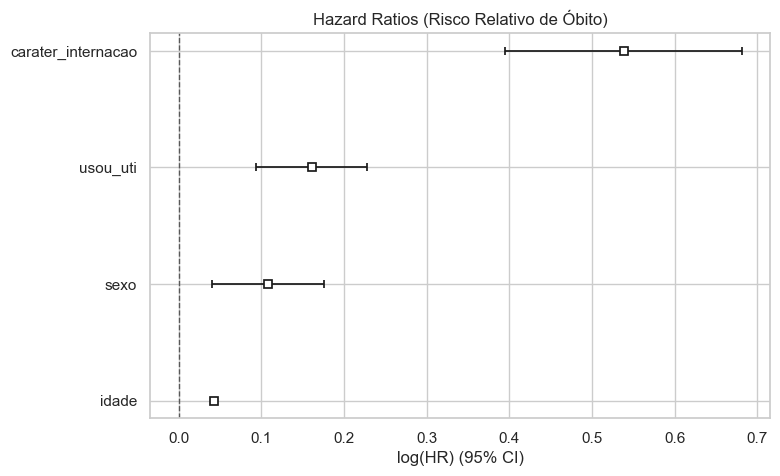


INTERPRETAÇÃO DO HAZARD RATIO (exp(coef)):
- Valores > 1 indicam que a variável AUMENTA o risco de óbito (acelera o evento).
- Valores < 1 indicam que a variável REDUZ o risco de óbito (proteção).


In [5]:
# Para o CoxPH, precisamos de variáveis numéricas/binárias puras e sem NAs
# Selecionamos algumas de impacto comprovado
cols_cox = ['dias_permanencia', 'indicador_obito', 'idade', 'sexo', 'carater_internacao', 'uti_mes_total']
df_cox = df[cols_cox].copy()

# Tratamento
df_cox = df_cox.dropna()
# Binarizar Sexo: 0 = Masculino, 1 = Feminino
df_cox['sexo'] = df_cox['sexo'].map({1: 0, 3: 1})
# Binarizar Caráter: 0 = Eletivo, 1 = Urgência
df_cox['carater_internacao'] = df_cox['carater_internacao'].map({1: 0, 2: 1})
# Binarizar UTI: 0 = Não, 1 = Sim (qualquer tempo na UTI)
df_cox['usou_uti'] = (df_cox['uti_mes_total'] > 0).astype(int)
df_cox.drop(columns=['uti_mes_total'], inplace=True)

# Ajuste do Modelo Cox
cph = CoxPHFitter()
cph.fit(df_cox, duration_col='dias_permanencia', event_col='indicador_obito')

# Resultados
print("=== Resumo do Modelo de Riscos Proporcionais de Cox ===")
cph.print_summary()

# Plotar os Hazard Ratios (Risco Relativo)
plt.figure(figsize=(8, 5))
cph.plot()
plt.title('Hazard Ratios (Risco Relativo de Óbito)')
plt.show()

print("\nINTERPRETAÇÃO DO HAZARD RATIO (exp(coef)):")
print("- Valores > 1 indicam que a variável AUMENTA o risco de óbito (acelera o evento).")
print("- Valores < 1 indicam que a variável REDUZ o risco de óbito (proteção).")